# Gated Recurrent Networks

### Gated Recurrent Cells fis vanishing gradient problem

- The main problem with vanilla RNN's which leads to a vanishing gradient problem is the **inability to filter the gradient signal as it passes through several time-steps**.
- Gated RNN's e.g. LSTM's **"gate" the information** as it flows through several time-steps **hence allowing us to model long-term dependencies**.

### Long short-term Memory (LSTM) Networks

- A type of RNN proposed by (Hochreiter & Schmidhuber, 1997) to **deal with the vanishing gradient problem**.
- A much more complex model than a vanilla RNN with lots more parameters
- Works in 3 steps: 
    1. **Forget** (some part of the state)
    2. **Update** (the state)
    3. **Output** (the final state)

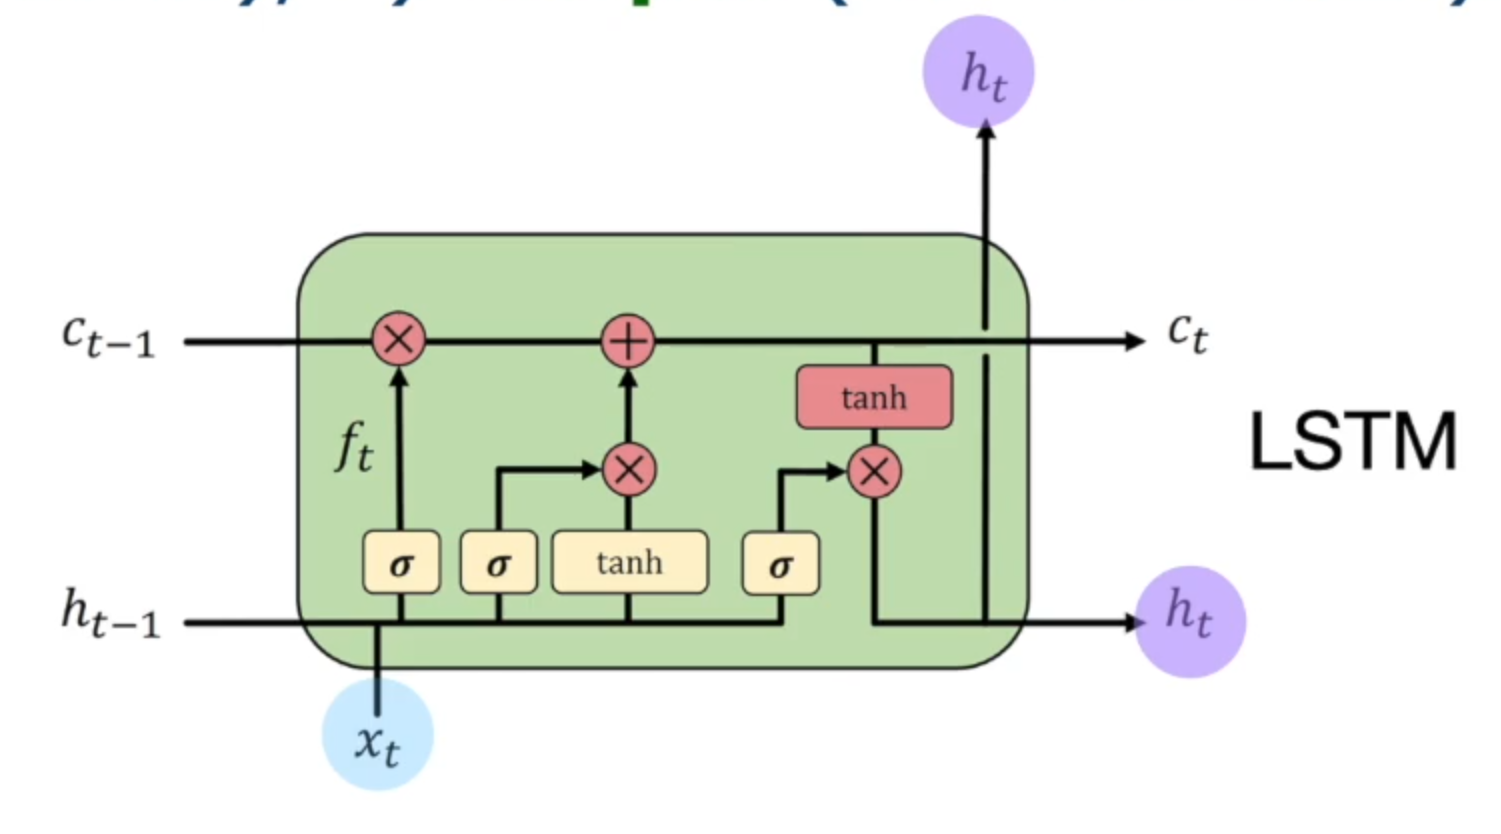 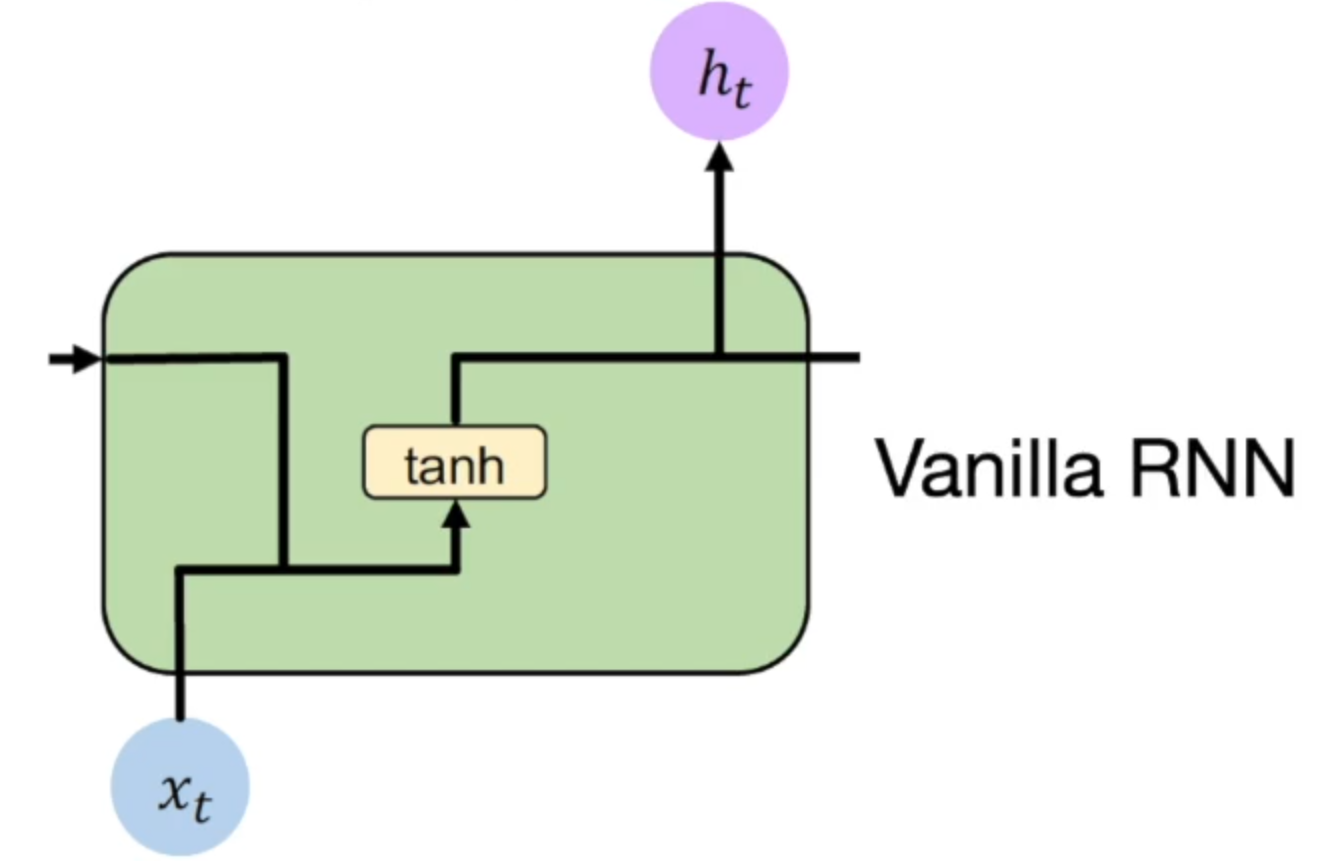

- On each time-step t, the LSTM maintains two states, a hidden state $h_t$ and a cell state $c_t$
    - The hidden state servers the same purpose as in vanilla RNN.
    - The cell state stores long-term information.
    - The LSTM can *erase*, *write*, and *read* information from the cell.
- There are **3 corresponding gates** that **control** what information is *erased*, *written*, and *read*:
    - On each step, each gate can be in one of three states: 1) **Open**, 2) **Closed**, or 3) **somewhere in between**.
    - **The gates are dynamic**, so their value is computed based on the current context.

### LTSM Details

- **Forget Gate**: Control what information is forgotten from the previous cell state $f_t = \sigma (W_fh_{t-1}+U_fx_t+b_f)$
- **Input Gate**: Controls what part of the new cell contents are written to the cell $i_t = \sigma (W_ih_{t-1}+U_ix_t+b_i)$
- **Output Game**: Control what part of the cell contents are output to the hidden state $ o_t = \sigma(W_oh_{t-1}+U_ox_t+b_o)$

$\sigma(.)$ represents the sigmoid function, hence all the gate values are between 0 and 1 and $b_{(.)}$ **represents the bias term**.

> Note: Typically, in this course we denote model parameters using $\theta$, however, we use $W$ above to make our notation consistent with the LSTM literature.

Now that we have seen the operationalization of the LSTM gates, let's see how the hidden and cell states are updated.

- **New Cell Content**: This is the new cell content to be written to the cell:
$\tilde{c}_t = tanh(W_ch_{t-1} + U_cx_t + b_c)$

> Note the similarity with the hidden state update of a vanilla RNN.

- **Cell State**: Erase (forget) some content from last cell state, and write (input) some new cell content: $c_t = f_t \cdot c_t + i_t \cdot \tilde{c}_t $

- **Hidden State**: Read (output) some content from the cell state $ h_t = o_t \cdot tanh c_t $

> Note that the gates are applied using element-wise product.

### LSTM Details Visualized

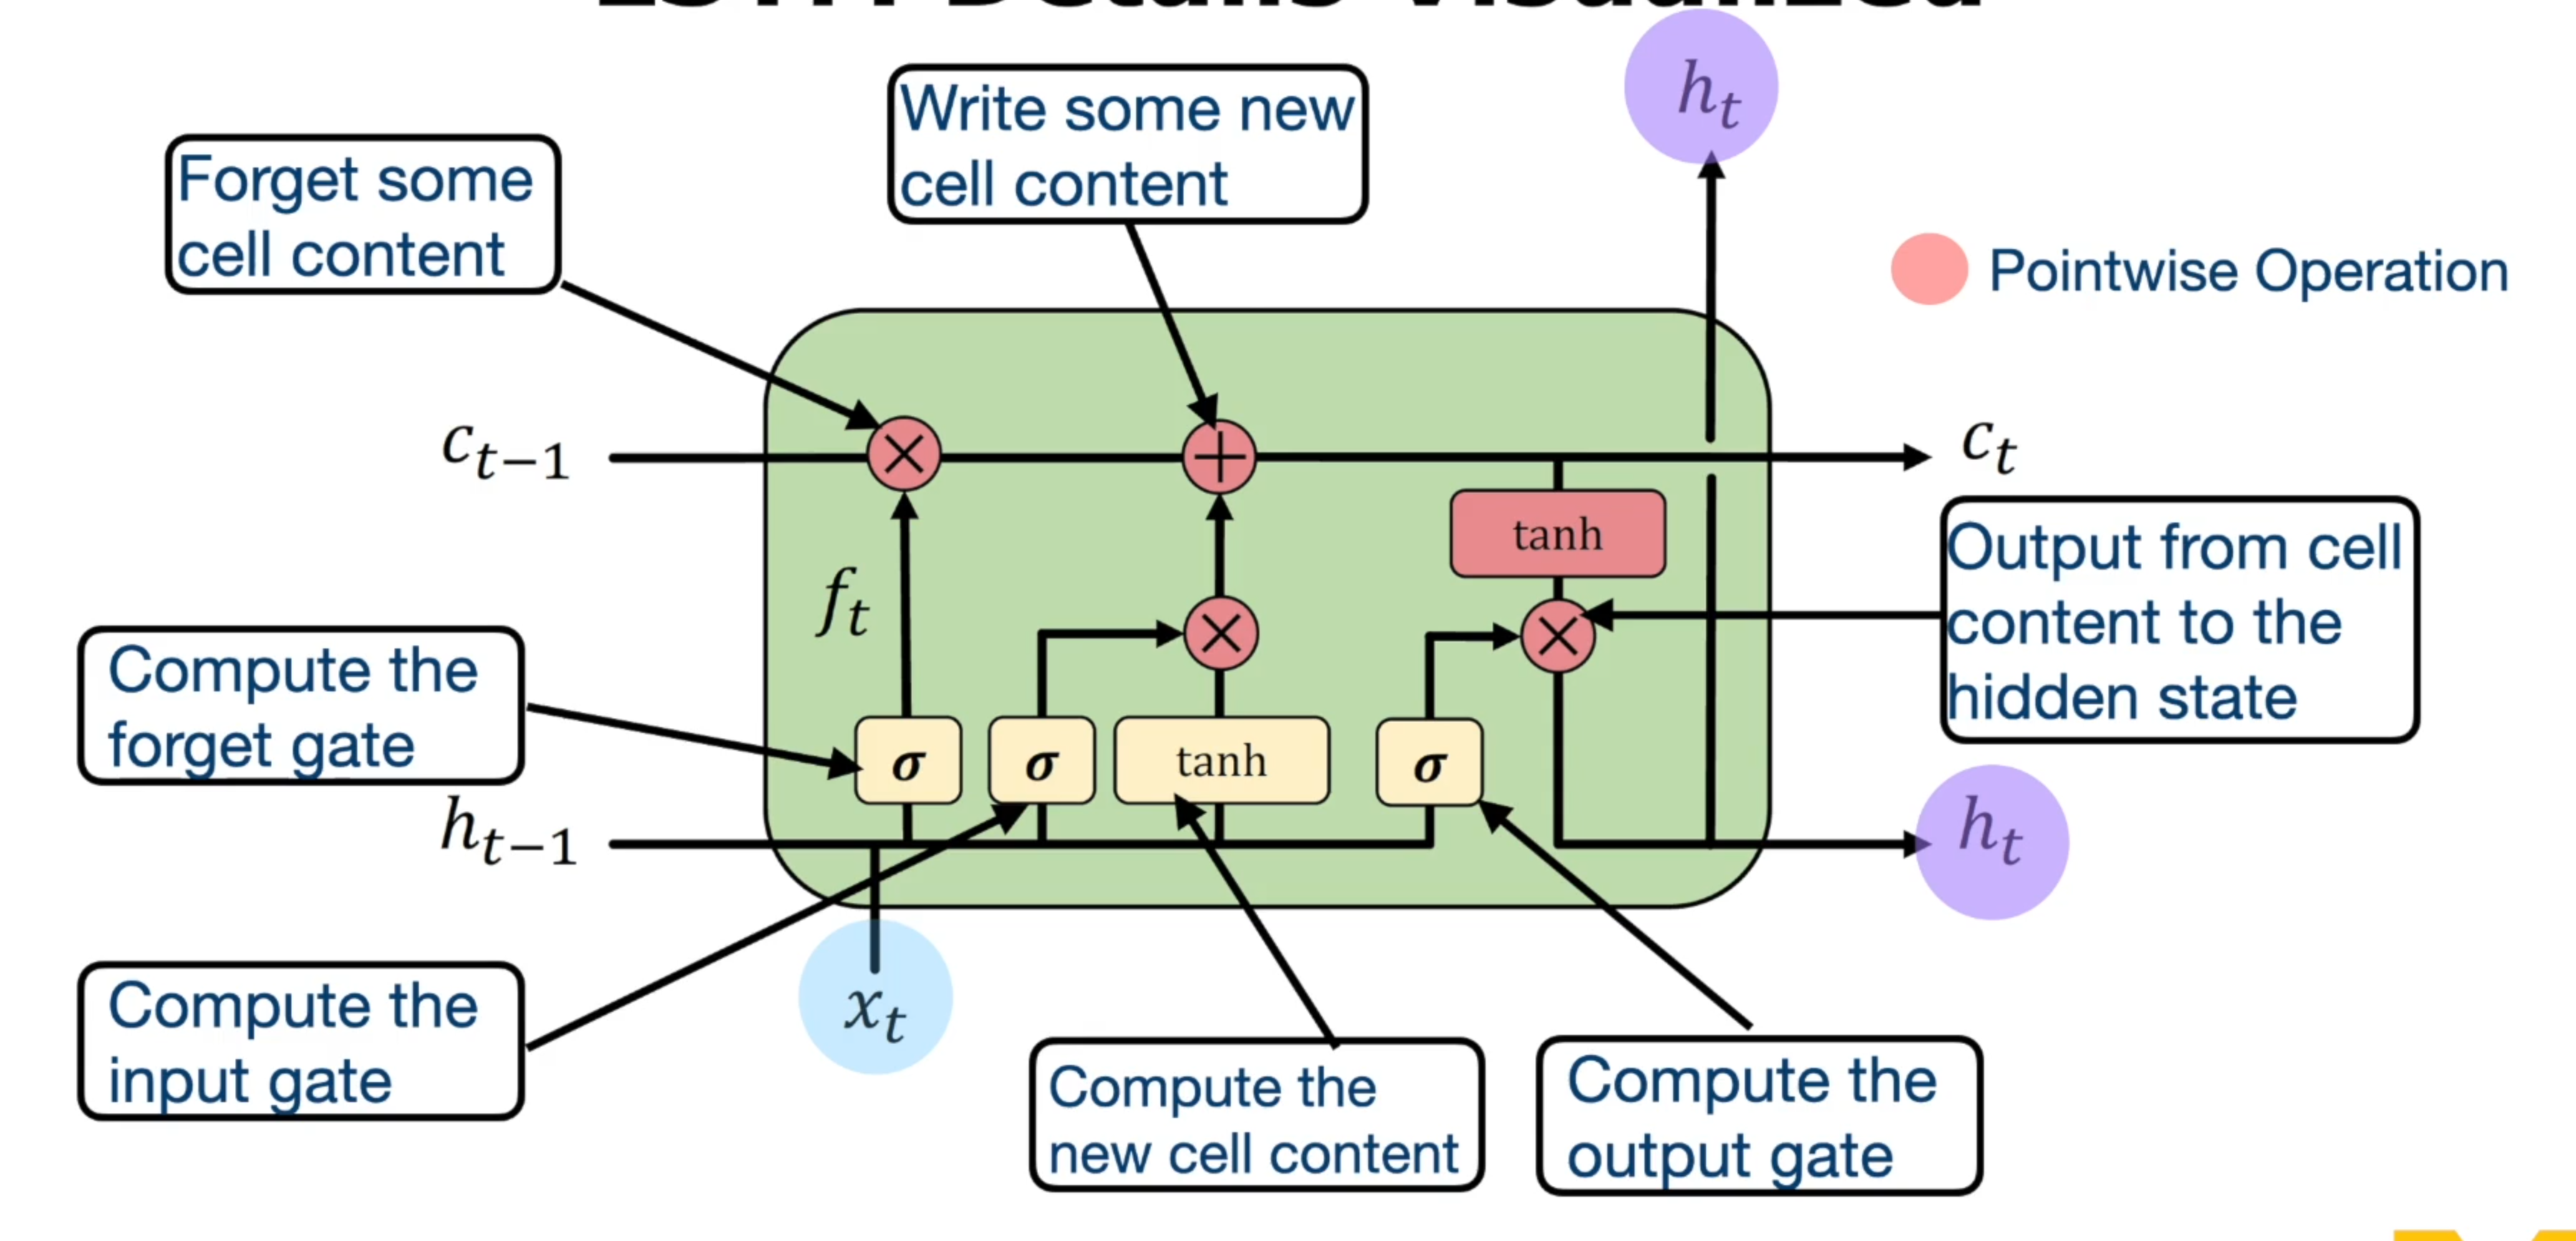

### Gated Recurrent Units (GRU): An alternative to LSTM's

- GRU was proposed by (Cho et al. 2014) as a **simplier alternative to LSTM**. There are many such alternatives, but GRU is the most wildly used.
- Is has **far fewer parameters** than LSTM, is **faster to train**, and gives **comparable performance**.
- Key-idea behind the model parsimony: It **does not maintain a separate cell state $c_t$** and **only has two gates to control the information flow**, a reset gate $r_t$ and an update gate $u_t$.
- For more details read the GRU paper: https://arxiv.org/pdf/1406.1078v3.pdf

### How do LSTM and GRU solve the vanishing gradient problem?

- LSTM/GRU **do not guarantee** that there is **no vanishing gradient problem!** However, they provide an **easy way to model long-term dependencies**.
- For instance, if the forget gate $f_t$ in the LSTM is set to remember everything then the information in the cell is preserved indefinitely.
- There is no corresponding mechanism in a "vanilla" RNN to preserve information in the hidden state.

### Is vanishing/exploding gradients just a RNN problem?

- No! It can be a problem for **all neural architectures** e.g. FFNN's, CNN's.
- But, it is **most salient for "deeper" architectures** as the gradient signal often attentuates over longer distances due to repeated multiplications done while backpropagation.
- **Residual or skip connections as made by ResNets** (as we saw in our CNN lecture) are another way to preserve information over longer distances in deeper architectures.

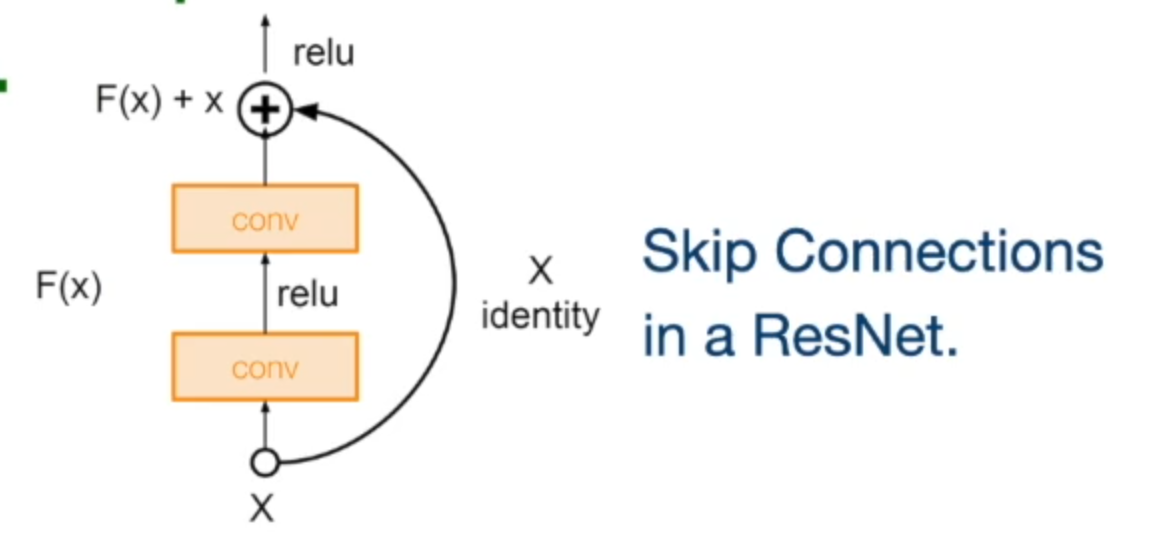